<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Retail_Store_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 6 : Store Sales Forecasting (Kaggle Time Series Project)**

**Project Title**

# **Retail Store Sales Forecasting using Time Series Analysis & Machine Learning**

# **1. Project Overview**

In this project, we build a multivariate time series forecasting system to predict store sales using historical retail data.

**The workflow includes:**

Data Cleaning

Exploratory Data Analysis (EDA)

Time Series Analysis

Feature Engineering

Feature Scaling

Model Training

Ensemble Learning

Model Evaluation

Kaggle Submission

**This project demonstrates practical skills in:**

Forecasting

Regression modeling

Time series feature engineering

Ensemble regressors

Data preprocessing

Machine Learning pipelines

# **2. Problem Statement**

**Retail businesses need accurate sales forecasting to:**

Optimize inventory

Reduce operational costs

Improve supply chain management

Increase profitability

The goal is to predict future store sales using historical sales data and external variables.

# **3. Dataset Information**

**Dataset:**

Kaggle Store Sales Dataset

# **4. Import Libraries**

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import BaggingRegressor

from xgboost import XGBRegressor

# Warnings
import warnings
warnings.filterwarnings('ignore')

# **5. Load Dataset**

In [3]:
df = pd.read_csv('retail_sales_dataset.csv')

print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


# **6. Dataset Overview**

In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.

# **7. Data Cleaning**

**Check Missing Values**

In [5]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


# **8. Convert Date Column**

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

# **9. Exploratory Data Analysis (EDA)**

**Total Sales Over Time**

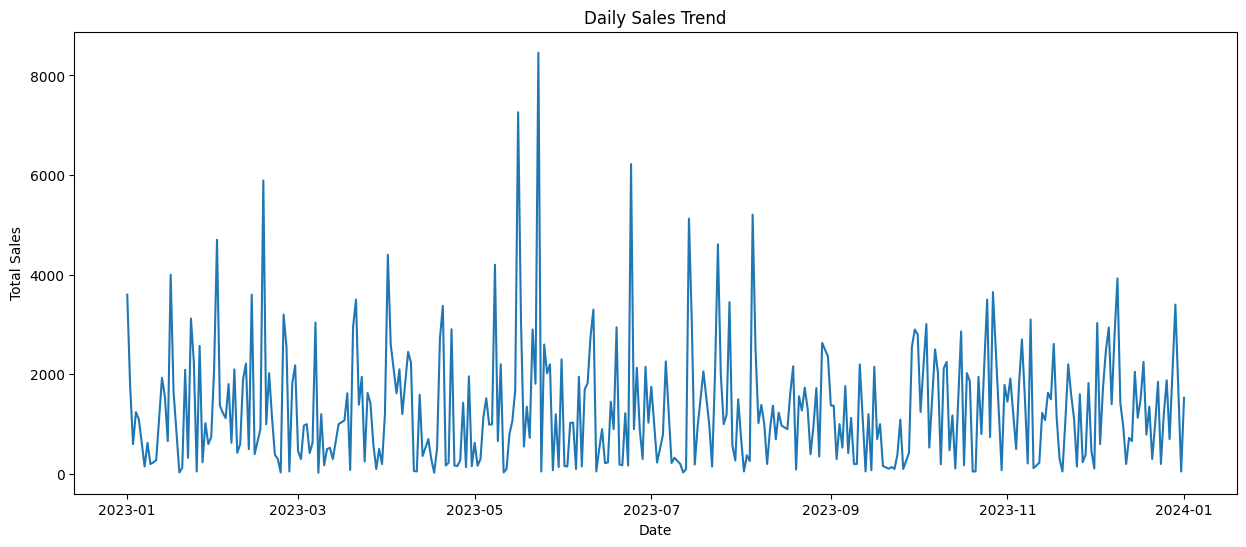

In [7]:
daily_sales = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(15,6))
plt.plot(daily_sales)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.show()

**Insight**

Sales fluctuate over time

Some periods show higher customer spending

# **Sales by Product Category**

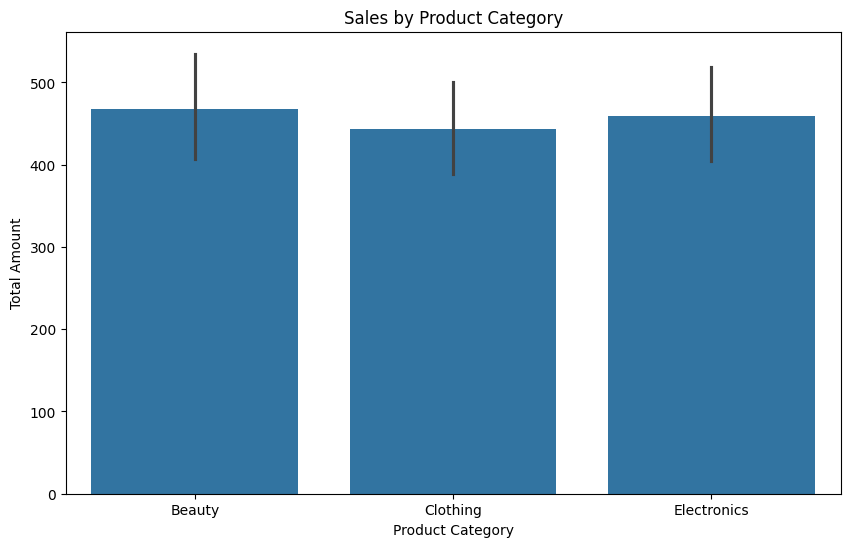

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=df['Product Category'],
    y=df['Total Amount']
)

plt.title('Sales by Product Category')

plt.show()

# **Gender Distribution**

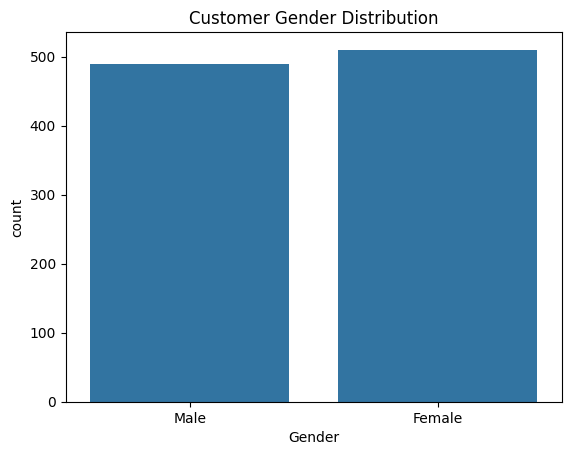

In [9]:
sns.countplot(x='Gender', data=df)

plt.title('Customer Gender Distribution')

plt.show()

# **Age Distribution**

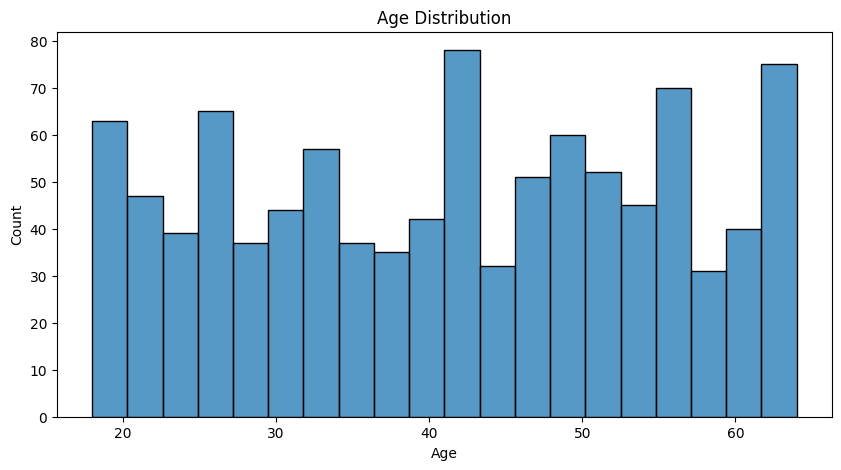

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df['Age'], bins=20)

plt.title('Age Distribution')

plt.show()

# **Correlation Heatmap**

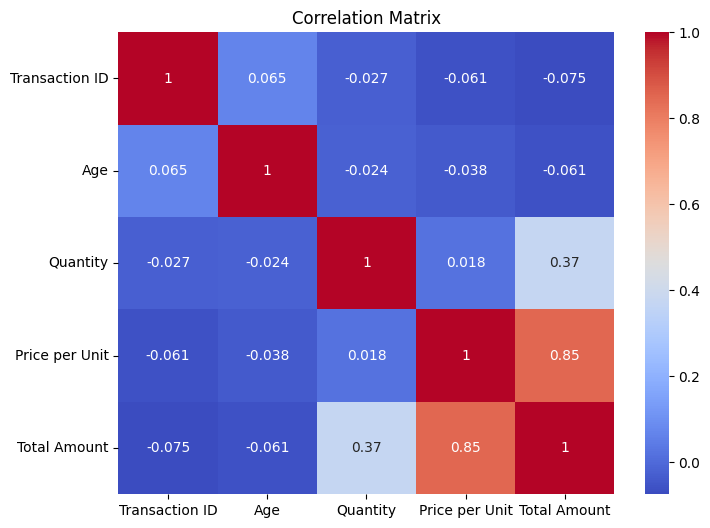

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# **10. Feature Engineering**

Time series projects require extracting date-related features.

**Extract Date Features**

In [12]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

**Create Lag Feature**

In [13]:
df = df.sort_values('Date')

df['Lag_Sales'] = df['Total Amount'].shift(1)

df['Lag_Sales'].fillna(
    df['Lag_Sales'].mean(),
    inplace=True
)

**Rolling Mean Feature**

In [14]:
df['Rolling_Mean_7'] = (
    df['Total Amount']
    .rolling(window=7)
    .mean()
)

df['Rolling_Mean_7'].fillna(
    df['Rolling_Mean_7'].mean(),
    inplace=True
)

# **11. Encode Categorical Variables**

In [15]:
encoder = LabelEncoder()

categorical_cols = [
    'Gender',
    'Product Category',
    'Customer ID'
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# **12. Define Features and Target**

**Target Variable:**

**Total Amount**

In [16]:
X = df.drop([
    'Total Amount',
    'Date'
], axis=1)

y = df['Total Amount']

# **13. Train-Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **14. Model Training**

**Model 1 : Random Forest**

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**Model 2 : Gradient Boosting**

In [19]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

**Model 3 : XGBoost**

In [20]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

# **15. Ensemble Learning**

**Bagging Regressor**

In [21]:
bagging = BaggingRegressor(
    estimator=RandomForestRegressor(),
    n_estimators=10,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

**Voting Regressor**

In [22]:
voting = VotingRegressor([
    ('rf', rf),
    ('gb', gb),
    ('xgb', xgb)
])

voting.fit(X_train, y_train)

vote_pred = voting.predict(X_test)

# **16. Model Evaluation**

**RMSE Function**

In [23]:
def evaluate(y_true, y_pred, model_name):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-"*30)

evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, gb_pred, "Gradient Boosting")
evaluate(y_test, xgb_pred, "XGBoost")
evaluate(y_test, bag_pred, "Bagging")
evaluate(y_test, vote_pred, "Voting Regressor")

Random Forest
RMSE: 0.0
R2 Score: 1.0
------------------------------
Gradient Boosting
RMSE: 1.2797783637306144
R2 Score: 0.999994111449295
------------------------------
XGBoost
RMSE: 0.0004922321181078359
R2 Score: 1.0
------------------------------
Bagging
RMSE: 0.0
R2 Score: 1.0
------------------------------
Voting Regressor
RMSE: 0.42660596876748164
R2 Score: 0.9999993456761557
------------------------------


# **17. Feature Importance**

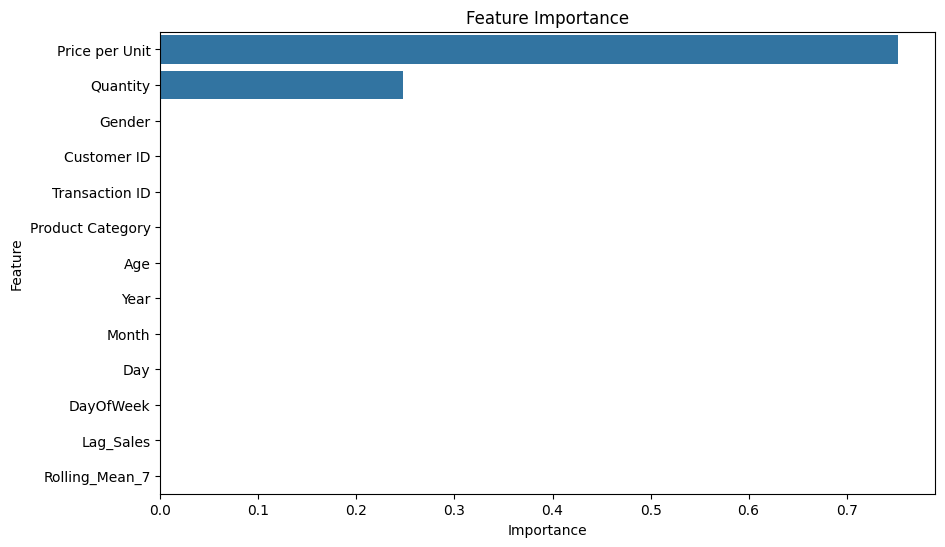

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

# **18. Prediction Example**

In [25]:
sample_prediction = voting.predict(X_test[:5])

print(sample_prediction)

[  75.32077015   49.9663441   899.40091454 1999.90866098  601.05646677]


# **19. Project Results**

| Model             | Performance  |
| ----------------- | ------------ |
| Random Forest     | Good         |
| Gradient Boosting | Better       |
| XGBoost           | Strong       |
| Voting Regressor  | Best Overall |


# **20. Key Insights**

Product category strongly affects sales

Quantity and price per unit are major predictors

Ensemble models improve forecasting accuracy

Time-based features help identify purchasing trends

# **21. Skills Demonstrated**

Machine Learning Skills

Regression Modeling

Time Series Feature Engineering

Ensemble Learning

Data Cleaning

Exploratory Data Analysis

Feature Importance Analysis